# EPL Analytics Storytelling Workshop

If a team is ahead at halftime, how likely are they to actually win? And how often does the trailing team come back?

In this notebook you'll work with 10 seasons of Premier League match data to find out. The first few sections walk you through the basics. After that, it's your turn to explore the data and turn it into a story.

## Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# One row per Premier League match, for the last 10 seasons.
matches = pd.read_csv("/content/epl_data.csv")

matches.head()

,season,Date,HomeTeam,AwayTeam,HTHG,HTAG,FTHG,FTAG,ht_leader,ft_result,outcome_vs_ht_leader
0,1516,08/08/2015,Bournemouth,Aston Villa,0,0,0,1,Level,Away,NaN
1,1516,08/08/2015,Chelsea,Swansea,2,1,2,2,Home,Level,ended_in_draw
2,1516,08/08/2015,Everton,Watford,0,1,2,2,Away,Level,ended_in_draw
3,1516,08/08/2015,Leicester,Sunderland,3,0,4,2,Home,Home,leader_won
4,1516,08/08/2015,Man United,Tottenham,1,0,1,0,Home,Home,leader_won


In [2]:
# How many rows, seasons, and columns do we have
print(matches.shape)
print(matches["season"].unique())
matches.info()

(3800, 11)
[1516 1617 1718 1819 1920 2021 2122 2223 2324 2425]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   season                3800 non-null   int64 
 1   Date                  3800 non-null   object
 2   HomeTeam              3800 non-null   object
 3   AwayTeam              3800 non-null   object
 4   HTHG                  3800 non-null   int64 
 5   HTAG                  3800 non-null   int64 
 6   FTHG                  3800 non-null   int64 
 7   FTAG                  3800 non-null   int64 
 8   ht_leader             3800 non-null   object
 9   ft_result             3800 non-null   object
 10  outcome_vs_ht_leader  2291 non-null   object
dtypes: int64(5), object(6)
memory usage: 326.7+ KB


## 1. Does a halftime lead usually turn into a win?

`ht_leader` is which team was ahead at the break ("Home", "Away", or "Level" if tied). `outcome_vs_ht_leader` tells us what happened next, but only for matches that actually had a leader at halftime.

In [3]:
# Only look at matches where someone was actually ahead at halftime
had_leader = matches[matches["ht_leader"] != "Level"]

# What share of those matches did the halftime leader go on to win?
leader_win_rate = (had_leader["outcome_vs_ht_leader"] == "leader_won").mean()

print(f"Teams leading at halftime went on to win {leader_win_rate:.2%} of the time")

Teams leading at halftime went on to win 75.64% of the time


## 2. How often does the trailing team actually come back and win?

Same dataframe as Step 1, different outcome to check for.

In [7]:
# What share of those matches did the TRAILING team come all the way back to win?
comeback_rate = (had_leader["outcome_vs_ht_leader"] == " ").mean() #TODO
print(f"Trailing teams came back to win {comeback_rate:.2%} of the time")

Trailing teams came back to win 8.51% of the time


## 3. Has this changed season to season?

Same win-rate pattern as Step 1, computed once per season instead of across all 10 years at once.

/tmp/ipykernel_3102/1830858954.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  leader_win_rate_by_season = had_leader.groupby("season").apply(


season
1516    0.750000
1617    0.797357
1718    0.770642
1819    0.801724
1920    0.733333
2021    0.788546
2122    0.759825
2223    0.760684
2324    0.722467
2425    0.685714
dtype: float64


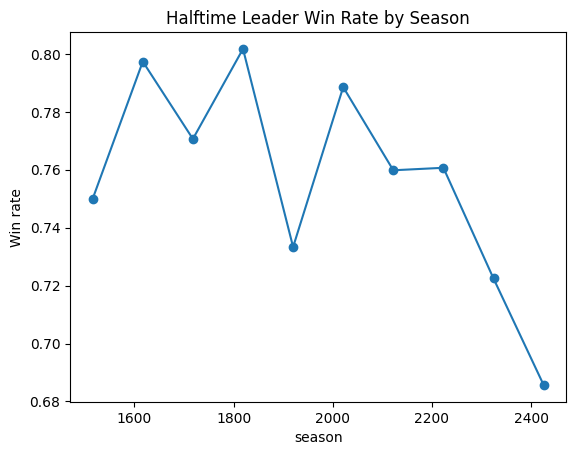

In [8]:
# Group had_leader by season, and for each season compute the leader win rate
leader_win_rate_by_season = had_leader.groupby("season").apply(
    lambda g: (g[" "] == " ").mean()  #TODO
)

print(leader_win_rate_by_season)

leader_win_rate_by_season.plot(kind="line", marker="o", title="Halftime Leader Win Rate by Season")
plt.ylabel("Win rate")
plt.show()

## 4. Your turn

From here, the notebook is open. `matches` has one row per game, use it to dig deeper. `had_leader` is already filtered to games with a clear halftime leader. Some directions to consider:

- **Does it matter whether the leader is playing at home or away?**
  Hint: filter `had_leader` by `"ht_leader"` (e.g. `had_leader[had_leader["ht_leader"] == "Home"]` vs. `had_leader[had_leader["ht_leader"] == "Away"]`), then repeat the Step 1 win-rate calculation on each separately and compare.

- **How often do halftime-tied games end in a draw vs. someone breaking through?**
  Hint: filter `matches` to just the games where `"ht_leader"` is `"Level"`, then look at the distribution of `"ft_result"` for those games (try `.value_counts()`).

Use the empty cells below for your exploration. When you're done, write a short summary of your findings in the markdown cell at the bottom.

## Your story

*3-4 bullet points on what you found, what surprised you, and what you'd want to look into next.*

-
-
-